<a href="https://colab.research.google.com/github/sicelomathambo-ship-it/fitai_monorepo/blob/main/LA3_Matambo_Sicelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Assignment 3: Text Classification with Deep Learning (GRU / LSTM + GloVe)

**Author:** Sicelo Matambo
**ASU ID:** <!-- REPLACE with your ASU ID (e.g., 1200000000) -->
**File created:** 2026-09-24

This notebook uses recurrent neural networks (GRU and LSTM) with pre-trained
GloVe word embeddings (glove.6B.100d) to classify the sentiment of Yelp
restaurant reviews. Each architecture is trained twice: once with the GloVe
embeddings **frozen** (not updated during training) and once with GloVe-initialized
**trainable** embeddings (fine-tuned during training). The four deep-learning models are then
compared with the best model from Lab 2 (TF-IDF with 1000 features + LinearSVC), using the
**same** 80/20 train/test split.

> **Before running:** in Colab, go to **Runtime → Change runtime type → Hardware accelerator: T4 GPU**.
> The RNN models train in a few minutes on a T4. On CPU they are much slower.


In [11]:
# =====================================================================
# Code Cell 1 - Import all necessary libraries and the restaurant review data
#   - Import TensorFlow/Keras (deep learning), numpy, pandas, re, nltk,
#     scikit-learn (split, TF-IDF, SVM, metrics) and matplotlib (plots)
#   - Upload / load restaurant_reviews_az.csv
# =====================================================================

import io
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras: tokenizer, padding, layers, model, callbacks
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import Constant

# scikit-learn: splitting, TF-IDF + SVM (Lab 2 best model), metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

# nltk resources used for basic text processing (stopwords)
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Confirm the GPU is visible (should list one GPU on a T4 runtime)
print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

# --- Import all the restaurant review data ---
# Upload restaurant_reviews_az.csv when the file picker appears.
from google.colab import files
uploaded = files.upload()

# Read the CSV that was just uploaded (uses the first uploaded file)
csv_name = next(iter(uploaded))
print("Loading:", csv_name)
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

print("Shape:", df.shape)
df.head()


TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving restaurant_reviews_az (6).csv to restaurant_reviews_az (6) (1).csv
Loading: restaurant_reviews_az (6) (1).csv
Shape: (48147, 9)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",1/27/2020 22:59
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,4/19/2020 5:33
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2/29/2020 19:43
3,E_ABvFCNVLbfOgRg3Pv1KQ,9MExTQ76GSKhxSWnTS901g,V9XlikTxq0My4gE8LULsjw,5,0,0,0,I've gone to claim Jumpers all over the US and...,3/14/2020 21:47
4,Rd222CrrnXkXukR2iWj69g,LPxuausjvDN88uPr-Q4cQA,CA5BOxKRDPGJgdUQ8OUOpw,4,1,0,0,"If you haven't been to Maynard's kitchen, it'...",1/17/2020 20:32


In [12]:
# =====================================================================
# Code Cell 2 - Remove 3-star reviews and create the Sentiment column
#   - Drop reviews with a 3-star rating (neutral)
#   - 1 or 2 stars  -> Sentiment = 0 (negative)
#   - 4 or 5 stars  -> Sentiment = 1 (positive)
#   - Print the class counts
# =====================================================================

# Keep only rows with a valid star rating and non-empty text
df = df.dropna(subset=['stars', 'text']).copy()
df['stars'] = df['stars'].astype(int)

# Remove the neutral (3-star) reviews
df = df[df['stars'] != 3].copy()

# Create the Sentiment label
df['Sentiment'] = np.where(df['stars'] >= 4, 1, 0)

print("Rows after removing 3-star reviews:", len(df))
print("Sentiment distribution:")
print(df['Sentiment'].value_counts())
print("\nSentiment proportions:")
print(df['Sentiment'].value_counts(normalize=True).round(4))
df[['stars', 'Sentiment', 'text']].head()


Rows after removing 3-star reviews: 44093
Sentiment distribution:
Sentiment
1    31781
0    12312
Name: count, dtype: int64

Sentiment proportions:
Sentiment
1    0.7208
0    0.2792
Name: proportion, dtype: float64


,stars,Sentiment,text
1,5,1,Pandemic pit stop to have an ice cream.... onl...
2,5,1,I was lucky enough to go to the soft opening a...
3,5,1,I've gone to claim Jumpers all over the US and...
4,4,1,"If you haven't been to Maynard's kitchen, it'..."
5,1,0,I stay at the Main Hotel at the Casino from Ju...


In [13]:
# =====================================================================
# Code Cell 3 - Data processing + train/test split (80% train / 20% test)
#   - Basic text cleaning (lowercase, strip URLs/HTML/non-letters), same
#     approach as Lab 2
#   - Remove English stopwords (nltk) BUT keep negation words
#     (not, no, nor, never and the n't forms)
#   - 80/20 split: train_test_split(test_size=0.20, random_state=42,
#     stratify=labels) -- identical to Lab 2
#   - Keras Tokenizer fit on the TRAINING text only (num_words=20000,
#     oov_token), then texts_to_sequences on train and test
#   - pad_sequences to a fixed maxlen (length percentiles printed to
#     justify the choice)
#   - Keep the cleaned train/test text for the Lab 2 model (Cell 9)
# =====================================================================

# --- Stopwords, with negations preserved ---
# Why keep negations? The standard nltk list contains words such as
# "not", "no", "nor", "don't", "wasn't", "didn". Removing them flips
# the meaning of phrases like "not good" -> "good" or "never coming back"
# -> "coming back". Bag-of-words models lose some signal, but a GRU/LSTM
# reads words IN ORDER and can learn that "not" reverses what follows, so
# the negation words must stay in the text.
negation_words = {'no', 'not', 'nor', 'never'}
nltk_stop = set(stopwords.words('english'))
# Also keep every n't form in the nltk list ("don't", "wasn't", ...) and
# their apostrophe-less stems ("don", "wasn", "didn", ...)
negation_words |= {w for w in nltk_stop if w.endswith("n't")}
negation_words |= {w[:-2] for w in nltk_stop if w.endswith("n't")}
stop_words = nltk_stop - negation_words

def clean_text(text):
    text = str(text).lower()
    text = text.replace('\u2019', "'")               # curly -> straight apostrophe
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove URLs
    text = re.sub(r'<.*?>', ' ', text)               # remove HTML tags
    # Expand n't forms BEFORE stripping punctuation, so "didn't" -> "did not"
    # (otherwise it would become "didn t" and the negation would be lost)
    text = re.sub(r"\bwon't\b", 'will not', text)
    text = re.sub(r"\bcan't\b", 'can not', text)
    text = re.sub(r"n't\b", ' not', text)
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep letters only
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Quick check that negations survive cleaning
print(clean_text("The food wasn't good and I won't be back. Never again, NOT worth it!"))

# Build a modelling frame: cleaned text + label
model_df = pd.DataFrame({
    'clean_text': df['text'].astype(str).map(clean_text).values,
    'Sentiment':  df['Sentiment'].values,
})

# 80/20 split, stratified so class balance is preserved in both sets
# (same arguments as Lab 2 -> same train/test rows)
train_df, test_df = train_test_split(
    model_df, test_size=0.20, random_state=42, stratify=model_df['Sentiment'])

# Cleaned text kept for the TF-IDF + SVM model in Cell 9
X_train_text = train_df['clean_text']
X_test_text  = test_df['clean_text']
y_train = train_df['Sentiment'].values
y_test  = test_df['Sentiment'].values

print("Train size:", len(train_df), " Test size:", len(test_df))

# --- Keras Tokenizer: fit on TRAINING text only (no test leakage) ---
MAX_WORDS = 20000          # keep the 20,000 most frequent training words
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

# Convert text to integer sequences
train_seqs = tokenizer.texts_to_sequences(X_train_text)
test_seqs  = tokenizer.texts_to_sequences(X_test_text)

# Vocabulary size used by the Embedding layer (+1 for the padding index 0)
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print("Unique words in training text:", len(tokenizer.word_index))
print("Vocabulary size used (vocab_size):", vocab_size)

# --- Choose maxlen from the distribution of (cleaned) review lengths ---
seq_lens = np.array([len(s) for s in train_seqs])
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th percentile of sequence length: {np.percentile(seq_lens, p):.0f} tokens")
# 200 tokens covers the large majority of reviews (see percentiles above)
# while keeping RNN training fast; longer reviews are truncated.
MAX_LEN = 200
print(f"MAX_LEN = {MAX_LEN} -> {np.mean(seq_lens <= MAX_LEN):.2%} of training reviews fit without truncation")

# --- Pad / truncate every sequence to MAX_LEN ---
# padding='pre' puts the zeros BEFORE the text, so the RNN's final hidden
# state is computed right after the real words (no mask needed, and it
# keeps the fast cuDNN GRU/LSTM kernel on the GPU). truncating='pre' keeps
# the END of long reviews, where people usually give their overall verdict.
X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='pre', truncating='pre')
print("Padded train shape:", X_train_pad.shape, " Padded test shape:", X_test_pad.shape)

# Dictionary to collect results for every model, for the final comparison
results = {}

# Reusable evaluation helper (same as Lab 2, plus macro F1 and training time)
def evaluate_model(name, y_true, y_pred, train_time=None):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    results[name] = {'Accuracy': acc, 'Macro F1': macro_f1,
                     'Train time (s)': train_time}
    print(f"===== {name} =====")
    print(f"Accuracy: {acc:.4f}   Macro F1: {macro_f1:.4f}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    print("Confusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_true, y_pred))
    return acc


food not good not back never not worth
Train size: 35274  Test size: 8819
Unique words in training text: 30351
Vocabulary size used (vocab_size): 20000
  50th percentile of sequence length: 32 tokens
  75th percentile of sequence length: 55 tokens
  90th percentile of sequence length: 89 tokens
  95th percentile of sequence length: 116 tokens
  99th percentile of sequence length: 191 tokens
MAX_LEN = 200 -> 99.18% of training reviews fit without truncation
Padded train shape: (35274, 200)  Padded test shape: (8819, 200)


In [14]:
# =====================================================================
# Code Cell 4 - Download pre-trained GloVe embeddings (glove.6B.100d)
#   - Download glove.6B.zip and unzip ONLY glove.6B.100d.txt
#   - Load the word vectors into a dictionary
#   - Build the embedding matrix (vocab_size x 100) for our tokenizer
#   - Print vocabulary coverage
# =====================================================================

# --- Download (about 820 MB zip; skipped if the file is already present) ---
!if [ ! -f glove.6B.100d.txt ]; then wget -q --show-progress https://nlp.stanford.edu/data/glove.6B.zip && unzip -o -q glove.6B.zip glove.6B.100d.txt && rm -f glove.6B.zip; fi
# Fallback mirror if the Stanford server is slow or down (uncomment):
# !wget -q --show-progress https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip && unzip -o -q glove.6B.zip glove.6B.100d.txt && rm -f glove.6B.zip

GLOVE_PATH = 'glove.6B.100d.txt'
EMBED_DIM = 100

# --- Load GloVe into a dictionary {word: 100-d vector} ---
glove_index = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        parts = line.rstrip().split(' ')
        glove_index[parts[0]] = np.asarray(parts[1:], dtype='float32')
print("GloVe word vectors loaded:", len(glove_index))

# --- Build the embedding matrix: row i = GloVe vector of the word with index i ---
# Row 0 is padding (all zeros); words not found in GloVe also stay zeros.
embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype='float32')
hits, misses = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    vec = glove_index.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        hits += 1
    else:
        misses += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print(f"Coverage: {hits} of {hits + misses} vocabulary words found in GloVe "
      f"({hits / max(hits + misses, 1):.2%}); {misses} missing (left as zeros)")


GloVe word vectors loaded: 400000
Embedding matrix shape: (20000, 100)
Coverage: 18019 of 19999 vocabulary words found in GloVe (90.10%); 1980 missing (left as zeros)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,031,937 (7.75 MB)

 Trainable params: 31,937 (124.75 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/5
249/249 - 4s - 17ms/step - accuracy: 0.8681 - loss: 0.3064 - val_accuracy: 0.9357 - val_loss: 0.1755
Epoch 2/5
249/249 - 3s - 11ms/step - accuracy: 0.9383 - loss: 0.1650 - val_accuracy: 0.9391 - val_loss: 0.1618
Epoch 3/5
249/249 - 3s - 13ms/step - accuracy: 0.9460 - loss: 0.1444 - val_accuracy: 0.9408 - val_loss: 0.1573
Epoch 4/5
249/249 - 3s - 14ms/step - accuracy: 0.9514 - loss: 0.1314 - val_accuracy: 0.9433 - val_loss: 0.1486
Epoch 5/5
249/249 - 3s - 11ms/step - accuracy: 0.9560 - loss: 0.1208 - val_accuracy: 0.9478 - val_loss: 0.1393

Training time: 16.6 seconds (5 epochs run)


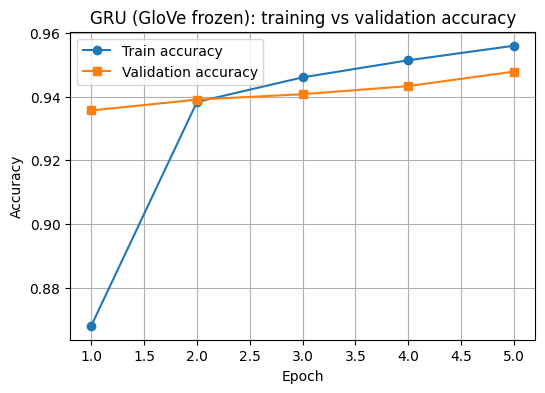

===== GRU (GloVe frozen) =====
Accuracy: 0.9452   Macro F1: 0.9303

Classification report:
              precision    recall  f1-score   support

           0     0.9350    0.8640    0.8981      2463
           1     0.9488    0.9767    0.9626      6356

    accuracy                         0.9452      8819
   macro avg     0.9419    0.9204    0.9303      8819
weighted avg     0.9449    0.9452    0.9445      8819

Confusion matrix (rows=true, cols=pred):
[[2128  335]
 [ 148 6208]]


In [15]:
# =====================================================================
# Code Cell 5 - GRU with pre-trained GloVe embeddings, FROZEN (trainable=False)
#   - Shared model builder build_rnn(cell_type, trainable), used in Cells 5-8
#   - Architecture: Embedding (GloVe) -> one 64-unit GRU -> Dropout -> Dense(1, sigmoid)
#   - Fixed random seed (tf.keras.utils.set_random_seed(42)) for reproducibility
#   - model.summary()
#   - Train: up to 5 epochs, batch size 128, validation_split=0.1,
#     EarlyStopping on val_loss with restore_best_weights
#   - Record training time; plot training vs validation accuracy
#   - Evaluate on the test set with evaluate_model (threshold 0.5)
# =====================================================================

EPOCHS = 5
BATCH_SIZE = 128
RNN_UNITS = 64

def build_rnn(cell_type, trainable):
    # Build and compile a small RNN sentiment classifier.
    # cell_type: 'GRU' or 'LSTM'; trainable: fine-tune the GloVe embeddings or not
    tf.keras.utils.set_random_seed(42)      # same starting point for every model
    rnn_layer = GRU(RNN_UNITS) if cell_type == 'GRU' else LSTM(RNN_UNITS)
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        # Embedding initialized with the GloVe matrix; frozen or trainable
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                  embeddings_initializer=Constant(embedding_matrix),
                  trainable=trainable),
        rnn_layer,                          # one 64-unit GRU or LSTM layer
        Dropout(0.5),                       # regularization against overfitting
        Dense(1, activation='sigmoid'),     # probability of positive sentiment
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

def train_and_evaluate(name, cell_type, trainable):
    # Build, summarize, train (with timing), plot, and evaluate one model
    model = build_rnn(cell_type, trainable)
    model.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=1,
                               restore_best_weights=True)
    start = time.time()
    history = model.fit(X_train_pad, y_train,
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.1, callbacks=[early_stop],
                        verbose=2)
    train_time = time.time() - start
    print(f"\nTraining time: {train_time:.1f} seconds "
          f"({len(history.history['loss'])} epochs run)")

    # Plot training vs validation accuracy per epoch
    epochs_run = range(1, len(history.history['accuracy']) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs_run, history.history['accuracy'], 'o-', label='Train accuracy')
    plt.plot(epochs_run, history.history['val_accuracy'], 's-', label='Validation accuracy')
    plt.title(f'{name}: training vs validation accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.show()

    # Predict on the test set: probability >= 0.5 -> positive (1)
    probs = model.predict(X_test_pad, batch_size=512, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    evaluate_model(name, y_test, preds, train_time=train_time)
    return model, history

gru_frozen, hist_gru_frozen = train_and_evaluate("GRU (GloVe frozen)", 'GRU', trainable=False)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,042,305 (7.79 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/5
249/249 - 4s - 18ms/step - accuracy: 0.8710 - loss: 0.3034 - val_accuracy: 0.9189 - val_loss: 0.2052
Epoch 2/5
249/249 - 4s - 16ms/step - accuracy: 0.9253 - loss: 0.1922 - val_accuracy: 0.9320 - val_loss: 0.1857
Epoch 3/5
249/249 - 3s - 13ms/step - accuracy: 0.9371 - loss: 0.1638 - val_accuracy: 0.9396 - val_loss: 0.1783
Epoch 4/5
249/249 - 3s - 12ms/step - accuracy: 0.9448 - loss: 0.1452 - val_accuracy: 0.9461 - val_loss: 0.1464
Epoch 5/5
249/249 - 3s - 12ms/step - accuracy: 0.9515 - loss: 0.1294 - val_accuracy: 0.9527 - val_loss: 0.1326

Training time: 17.5 seconds (5 epochs run)


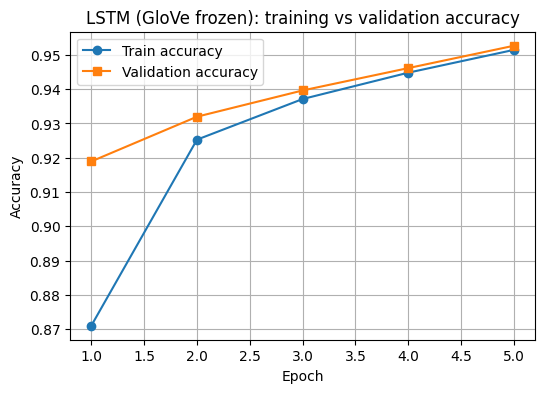

===== LSTM (GloVe frozen) =====
Accuracy: 0.9478   Macro F1: 0.9343

Classification report:
              precision    recall  f1-score   support

           0     0.9264    0.8835    0.9044      2463
           1     0.9556    0.9728    0.9641      6356

    accuracy                         0.9478      8819
   macro avg     0.9410    0.9281    0.9343      8819
weighted avg     0.9475    0.9478    0.9475      8819

Confusion matrix (rows=true, cols=pred):
[[2176  287]
 [ 173 6183]]


In [16]:
# =====================================================================
# Code Cell 6 - LSTM with pre-trained GloVe embeddings, FROZEN (trainable=False)
#   - Same builder / architecture as Cell 5, with one 64-unit LSTM layer
#   - model.summary(); train (5 epochs max, batch 128, validation_split=0.1,
#     EarlyStopping); record training time; plot accuracy curves
#   - Evaluate on the test set with evaluate_model (threshold 0.5)
# =====================================================================

lstm_frozen, hist_lstm_frozen = train_and_evaluate("LSTM (GloVe frozen)", 'LSTM', trainable=False)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,031,937 (7.75 MB)

 Trainable params: 2,031,937 (7.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
249/249 - 6s - 24ms/step - accuracy: 0.8850 - loss: 0.2651 - val_accuracy: 0.9546 - val_loss: 0.1326
Epoch 2/5
249/249 - 4s - 15ms/step - accuracy: 0.9611 - loss: 0.1073 - val_accuracy: 0.9592 - val_loss: 0.1174
Epoch 3/5
249/249 - 3s - 13ms/step - accuracy: 0.9745 - loss: 0.0739 - val_accuracy: 0.9586 - val_loss: 0.1296

Training time: 12.9 seconds (3 epochs run)


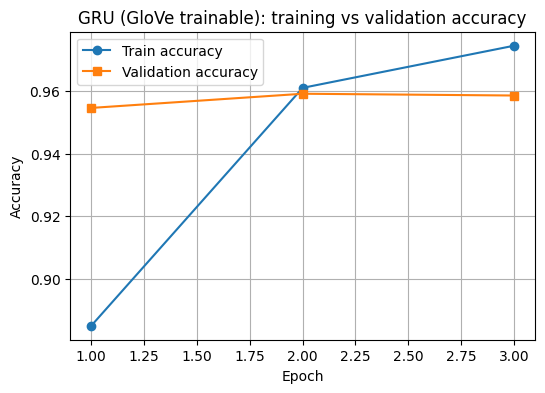

===== GRU (GloVe trainable) =====
Accuracy: 0.9565   Macro F1: 0.9456

Classification report:
              precision    recall  f1-score   support

           0     0.9294    0.9135    0.9214      2463
           1     0.9667    0.9731    0.9699      6356

    accuracy                         0.9565      8819
   macro avg     0.9480    0.9433    0.9456      8819
weighted avg     0.9563    0.9565    0.9563      8819

Confusion matrix (rows=true, cols=pred):
[[2250  213]
 [ 171 6185]]


In [17]:
# =====================================================================
# Code Cell 7 - GRU with GloVe-INITIALIZED, TRAINABLE embeddings
#   - Embedding starts from the GloVe matrix and is fine-tuned during
#     training (trainable=True), so vectors adapt to restaurant reviews
#   - model.summary(); train (5 epochs max, batch 128, validation_split=0.1,
#     EarlyStopping); record training time; plot accuracy curves
#   - Evaluate on the test set with evaluate_model (threshold 0.5)
# =====================================================================

gru_trainable, hist_gru_trainable = train_and_evaluate("GRU (GloVe trainable)", 'GRU', trainable=True)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,042,305 (7.79 MB)

 Trainable params: 2,042,305 (7.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
249/249 - 6s - 24ms/step - accuracy: 0.8937 - loss: 0.2511 - val_accuracy: 0.9459 - val_loss: 0.1526
Epoch 2/5
249/249 - 3s - 14ms/step - accuracy: 0.9580 - loss: 0.1172 - val_accuracy: 0.9561 - val_loss: 0.1358
Epoch 3/5
249/249 - 3s - 14ms/step - accuracy: 0.9704 - loss: 0.0842 - val_accuracy: 0.9592 - val_loss: 0.1233
Epoch 4/5
249/249 - 4s - 15ms/step - accuracy: 0.9797 - loss: 0.0615 - val_accuracy: 0.9558 - val_loss: 0.1422

Training time: 18.0 seconds (4 epochs run)


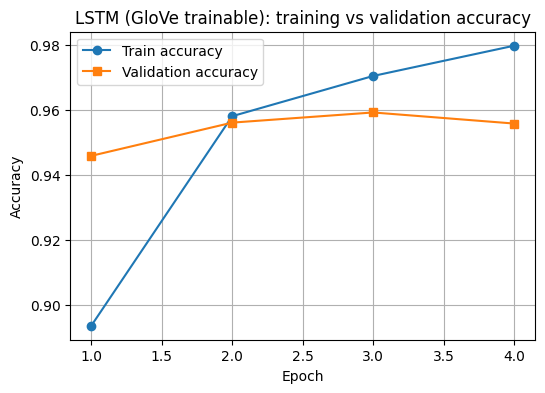

===== LSTM (GloVe trainable) =====
Accuracy: 0.9566   Macro F1: 0.9459

Classification report:
              precision    recall  f1-score   support

           0     0.9273    0.9164    0.9218      2463
           1     0.9677    0.9722    0.9699      6356

    accuracy                         0.9566      8819
   macro avg     0.9475    0.9443    0.9459      8819
weighted avg     0.9564    0.9566    0.9565      8819

Confusion matrix (rows=true, cols=pred):
[[2257  206]
 [ 177 6179]]


In [18]:
# =====================================================================
# Code Cell 8 - LSTM with GloVe-INITIALIZED, TRAINABLE embeddings
#   - Embedding starts from the GloVe matrix and is fine-tuned (trainable=True)
#   - model.summary(); train (5 epochs max, batch 128, validation_split=0.1,
#     EarlyStopping); record training time; plot accuracy curves
#   - Evaluate on the test set with evaluate_model (threshold 0.5)
# =====================================================================

lstm_trainable, hist_lstm_trainable = train_and_evaluate("LSTM (GloVe trainable)", 'LSTM', trainable=True)


In [19]:
# =====================================================================
# Code Cell 9 - Reproduce the Lab 2 best model + summary of all 5 models
#   - TF-IDF Vectorizer (max_features = 1000) + LinearSVC, trained on the
#     SAME 80/20 split (cleaned train/test text from Cell 3)
#   - Evaluate with evaluate_model; record training time
#   - Summary table of all 5 models sorted by accuracy, with macro F1 and
#     training time
#   Note: Lab 2 scored 0.9416 test accuracy with this model. The result here
#   can differ slightly because Cell 3 now KEEPS negation words.
# =====================================================================

start = time.time()
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)   # fit on train only
X_test_tfidf  = tfidf_vectorizer.transform(X_test_text)
svm_tfidf = LinearSVC()
svm_tfidf.fit(X_train_tfidf, y_train)
svm_time = time.time() - start

pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)
evaluate_model("SVM (TF-IDF 1000) - Lab 2 best", y_test, pred_svm_tfidf, train_time=svm_time)

# --- Summary comparison table of all models ---
summary = (pd.DataFrame.from_dict(results, orient='index')
           .rename_axis('Model').reset_index()
           .sort_values('Accuracy', ascending=False)
           .reset_index(drop=True))
summary['Accuracy'] = summary['Accuracy'].round(4)
summary['Macro F1'] = summary['Macro F1'].round(4)
summary['Train time (s)'] = summary['Train time (s)'].round(1)
print("\n==================== MODEL COMPARISON ====================")
print(summary.to_string(index=False))


===== SVM (TF-IDF 1000) - Lab 2 best =====
Accuracy: 0.9464   Macro F1: 0.9331

Classification report:
              precision    recall  f1-score   support

           0     0.9098    0.8969    0.9033      2463
           1     0.9603    0.9655    0.9629      6356

    accuracy                         0.9464      8819
   macro avg     0.9350    0.9312    0.9331      8819
weighted avg     0.9462    0.9464    0.9462      8819

Confusion matrix (rows=true, cols=pred):
[[2209  254]
 [ 219 6137]]

==================== MODEL COMPARISON ====================
                         Model  Accuracy  Macro F1  Train time (s)
        LSTM (GloVe trainable)    0.9566    0.9459            18.0
         GRU (GloVe trainable)    0.9565    0.9456            12.9
           LSTM (GloVe frozen)    0.9478    0.9343            17.5
SVM (TF-IDF 1000) - Lab 2 best    0.9464    0.9331             1.8
            GRU (GloVe frozen)    0.9452    0.9303            16.6


## Text Cell 10 - Model comparison and observations

> **⚠️ NOTE TO SELF, FILL IN BEFORE SUBMITTING:** this discussion was drafted **before** the
> notebook was run. Replace every **[bracketed placeholder]** with the exact value from the
> summary table printed at the end of Code Cell 9 (and the training logs and plots), then
> **adjust the wording wherever the actual ordering differs** from what is written here.
> Delete this note when done.

**Summary of results (from Code Cell 9).**

| Model | Accuracy | Macro F1 | Train time (s) |
|---|---|---|---|
| GRU (GloVe frozen) | [GRU frozen accuracy] | [GRU frozen macro F1] | [GRU frozen time] |
| LSTM (GloVe frozen) | [LSTM frozen accuracy] | [LSTM frozen macro F1] | [LSTM frozen time] |
| GRU (GloVe trainable) | [GRU trainable accuracy] | [GRU trainable macro F1] | [GRU trainable time] |
| LSTM (GloVe trainable) | [LSTM trainable accuracy] | [LSTM trainable macro F1] | [LSTM trainable time] |
| SVM (TF-IDF 1000), Lab 2 best | [SVM accuracy] | [SVM macro F1] | [SVM time] |

**GRU vs. LSTM.**
GRU and LSTM are both gated RNNs that can carry information across a long review. A GRU has
two gates and fewer parameters, while an LSTM has three gates plus a separate cell state. With the same
64 units, the GRU reached [GRU frozen accuracy] / [GRU trainable accuracy] (frozen / trainable)
and the LSTM reached [LSTM frozen accuracy] / [LSTM trainable accuracy]. [Edit: state which was
better, or that they were essentially tied.] On short-to-medium texts like reviews the two are
usually very close. The GRU is slightly cheaper to train because it has fewer parameters per unit.

**Frozen vs. trainable GloVe embeddings.**
Frozen GloVe vectors come from general Wikipedia/news text, where words like "bland", "crispy",
or "rude" do not carry any restaurant-specific sentiment. Letting the embeddings train lets them adapt to
this domain (for example, pushing "bland" toward negative). With trainable embeddings, accuracy
went from [GRU frozen accuracy] to [GRU trainable accuracy] (GRU) and from
[LSTM frozen accuracy] to [LSTM trainable accuracy] (LSTM). [Edit to match your results.]
The cost is up to 2 million extra trainable parameters (vocab_size × 100 = 20,000 × 100), which makes the model more likely to overfit.
Compare how far the training and validation accuracy curves drift apart in Cells 7-8 vs. Cells 5-6.

**Deep learning vs. the Lab 2 SVM.**
The best deep-learning model, [best DL model name], scored [best DL accuracy] against
[SVM accuracy] for TF-IDF + LinearSVC (Lab 2 reported 0.9416 with the same model). [Edit: say
whether the RNN beat the SVM, matched it, or fell short.] RNNs read words in order, so they can pick up
negation and phrasing ("not bad at all", "never coming back") that a 1000-feature
bag-of-words misses. In return they need far more computation, a GPU, and tuning, and they can be less stable
from run to run. A linear SVM on TF-IDF remains a very strong, fast baseline for review sentiment.

**Class imbalance.**
About 72% of the reviews are positive, so a model that always predicted "positive" would already score
about 72% accuracy. For that reason I also compare **macro F1** and the **recall of the negative
class (0)** from the classification reports. The best negative-class recall was
[best negative-class recall] for [model name]. [Edit: comment on whether any model sacrifices
negative recall for overall accuracy.] Class weights or a tuned decision threshold (instead of 0.5)
could raise negative recall if that matters more.

**Training time.**
The SVM trained in [SVM time] seconds, while the RNNs took between [fastest RNN time] and
[slowest RNN time] seconds on a T4 GPU. Trainable-embedding models are slower per epoch than frozen ones
because gradients also flow into the 20,000 × 100 embedding matrix.

**Overfitting.**
From the accuracy curves: [Edit: describe, e.g. "training accuracy kept rising while validation
accuracy flattened after epoch [N] for the trainable models"]. Dropout (0.5), a small
64-unit layer, a validation split, and EarlyStopping (restoring the weights with the best validation loss)
all help limit overfitting. The frozen-embedding models have far fewer trainable parameters and are
usually less prone to it.

**Overall takeaways.**
- Best model overall: [best model name] ([best accuracy] accuracy, [best macro F1] macro F1).
- [Edit: one line on GRU vs. LSTM.]
- [Edit: one line on frozen vs. trainable embeddings.]
- [Edit: one line on deep learning vs. the Lab 2 SVM, including the accuracy/cost trade-off.]


## Text Cell 11 - GenAI tools & collaboration acknowledgment

- **GenAI tools used:** I used an AI Tool. I reviewed, ran, and verified
  all code and results myself.
- **Collaborators:**


In [20]:
# =====================================================================
# Code Cell 12 - Render the notebook to HTML.
#   - Mount Google Drive
#   - Convert the saved notebook in "Colab Notebooks" to HTML with nbconvert
# =====================================================================
from google.colab import drive
drive.mount('/content/drive')

!jupyter nbconvert --to html \
"/content/drive/MyDrive/Colab Notebooks/LA3_Matambo_Sicelo.ipynb" \
--output="LA3_Matambo_Sicelo.html" \
--output-dir="/content/drive/MyDrive/Colab Notebooks"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/LA3_Matambo_Sicelo.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 425236 bytes to /content/drive/MyDrive/Colab Notebooks/LA3_Matambo_Sicelo.html
